# DATA-445: Homework Assignment 4

**Instructions**

- This homework assignment is worth **119** points.
- Please submit a **.ipynb** file to Blackboard.
- **Please strive for clarity and organization.**
- **AI usage**:
  - AI use is strictly **prohibited** for conceptual exercises.
  - For applied (Python) exercises, you may use AI exclusively for **debugging**. Do not use AI to generate answers.
- **Due Date: October 2, 2026, by 11:59 PM.**

## Exercise 1

(5 points) What is a perceptron? Be specific.

A perceptron is a simple neural network with a single layer of inputs and a sign function. it takes inputs against weights combines them and then uses an activation function in the case of perceptron it is a sign function and gives output that is binary.

## Exercise 2

(5 points) What are the different types of perceptrons? Briefly describe each of them.

there are singe layer perceptrons and multi layered perceptrons. 

single layer perceptrons has an input layer and output layer while a multi layered perceptron also has these it also has one or more hidden layers to model non linear data. So, MLP uses non linear activation function to model these non linear data.

## Exercise 3

(5 points) What is a hard margin in a support vector machine model? Be specific.

a hard margin seperates the observations with the requirement of no training errors so all observations are classified correctly. so if data is noisy and overlaps happen a hard margin will fail in classification.

## Exercise 4

(4 points) The effectiveness of a support vector machine model depends on:

(a) kernel  
(b) kernel parameters  
(c) penalty cost parameter  
(d) All of the above  
(e) None of the above

d

## Exercise 5

(4 points) What is/are **true** about kernel in SVM?

(a) Kernel function map low dimensional data into high dimensional space.  
(b) Kernel function map high dimensional data into low dimensional space.  
(c) It is a similarity function.  
(d) (a) and (c)  
(e) (b) and (c)  
(f) (a), (b) and (c)  
(g) None of the above

d

## Exercise 6

(4 points) Which of the following statements is **true** regarding the role of the activation function in the hidden layer(s) of a multi-layer perceptron (MLP)?

(a) It has no effect on the model's ability to learn non-linear patterns.  
(b) It allows the network to learn and approximate non-linear decision boundaries.  
(c) It is only necessary in the output layer, not in the hidden layer(s).  
(d) It converts the MLP into a linear model, regardless of the number of hidden layers.  
(e) None of the above.

b

## Exercise 7

(5 points) What is a **soft margin** in a support vector machine model? How does the penalty (cost) parameter $C$ affect the trade-off between the width of the margin and the number of misclassified observations? Be specific.

a soft margin allows some observations to be misclassified and in the margin. The parameter penalty C affects the trade off between the width of the margin and the number of misclassified observations.

a smaller penalty c tolerates more violations for a wider margin, while a larger penalty C narrows the margin and penalizes misclassified observations more.

## Exercise 8

Consider the `framingham.csv` data file. The dataset is publically available on the Kaggle website, and it is from an ongoing cardiovascular study on residents of the town of Framingham, Massachusetts. The classification goal is to predict whether the patient has 10-year risk of future coronary heart disease (CHD). The dataset provides the patients' information. It includes over 4,000 records and 15 attributes. Each attribute is a potential risk factor. There are both demographic, behavioral and medical risk factors.

- **Demographic**:
  - Sex: male or female (Nominal)
  - Age: Age of the patient (Continuous - Although the recorded ages have been truncated to whole numbers, the concept of age is continuous)

- **Behavioral**
  - Current Smoker: whether or not the patient is a current smoker (Nominal)
  - Cigs Per Day: the number of cigarettes that the person smoked on average in one day (can be considered continuous as one can have any number of cigarettes, even half a cigarette)

- **Medical (history)**
  - BP Meds: whether or not the patient was on blood pressure medication (Nominal)
  - Prevalent Stroke: whether or not the patient had previously had a stroke (Nominal)
  - Prevalent Hyp: whether or not the patient was hypertensive (Nominal)
  - Diabetes: whether or not the patient had diabetes (Nominal)

- **Medical (current)**
  - Tot Chol: total cholesterol level (Continuous)
  - Sys BP: systolic blood pressure (Continuous)
  - Dia BP: diastolic blood pressure (Continuous)
  - BMI: Body Mass Index (Continuous)
  - Heart Rate: heart rate (Continuous - In medical research, variables such as heart rate though in fact discrete, yet are considered continuous because of large number of possible values.)
  - Glucose: glucose level (Continuous)

- **Predict variable (desired target)**
  - 10 year risk of coronary heart disease CHD (binary: "1", means "Yes", "0" means "No")

**In Python**, answer the following:

### (a)

(4 points) Using the `pandas` library, read the csv data file and create a data-frame called `heart`.

In [2]:
import pandas as pd

heart = pd.read_csv("framingham.csv")
heart.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


### (b)

(3 points) Remove observations with missing values.

In [5]:
heart = heart.dropna()
heart.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

### (c)

(60 points) Using `age`, `currentSmoker`, `totChol`, `BMI`, and `heartRate` as the predictor variables, and `TenYearCHD` as the target variable, do the following:

#### (i)

Set up a 5-fold cross-validation splitter (e.g., `StratifiedKFold` with `n_splits = 5`) on the predictor and target variables, and generate the `train`/`validation` indices for each of the 5 folds.

In [6]:
from sklearn.model_selection import StratifiedKFold

x = heart[['age','currentSmoker','totChol','BMI','heartRate']]
y = heart['TenYearCHD']

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kfold.split(x, y):
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]


#### (ii)

Using `MinMaxScaler`, transform the input variables of each fold's `train` and `validation` sets to 0-1 scale. This scaling must be applied independently within each fold, before building any of the models below.

In [7]:
from sklearn.preprocessing import MinMaxScaler

for train_index, test_index in kfold.split(x, y):
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    scaler = MinMaxScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

**Model 1**: Using 5-fold cross-validation, build a multi-layer perceptron model with one single hidden layer with 4 neurons (hyperbolic tangent as the activation function) on each fold. Use the stochastic descent gradient as the method to estimate the weights (`solver = 'sgd'`). Use `max_iter = 1000` and `batch_size = 500` to build the model. After that, use the model to predict on the validation fold. Using 15% as the cut-off value, report the recall of this model for each of the 5 folds.

In [18]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import recall_score

recalls_1=[]

for train_index, test_index in kfold.split(x, y):
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    scaler = MinMaxScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    
    md = MLPClassifier(hidden_layer_sizes=(4,), 
                       solver = 'sgd',
                       activation= 'tanh',
                       max_iter=1000, 
                       batch_size= 500,
                       random_state=42)
    
    md.fit(x_train_scaled, y_train)
    
    prob = md.predict_proba(x_test_scaled)[:, 1]
    pred = (prob >= 0.15).astype(int)
    
    recall = recall_score(y_test, pred)
    print(f"Recall: {recall}")
    recalls_1.append(recall)

Recall: 1.0
Recall: 1.0
Recall: 1.0
Recall: 1.0
Recall: 1.0


**Model 2**: Using 5-fold cross-validation, build a multi-layer perceptron model with one single hidden layer with 4 neurons (ReLU as the activation function) on each fold. Use the stochastic descent gradient as the method to estimate the weights (`solver = 'sgd'`). Use `max_iter = 1000` and `batch_size = 500` to build the model. After that, use the model to predict on the validation fold. Using 15% as the cut-off value, report the recall of this model for each of the 5 folds.

In [19]:
recalls_2=[]

for train_index, test_index in kfold.split(x, y):
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    scaler = MinMaxScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    
    md = MLPClassifier(hidden_layer_sizes=(4,), 
                       solver = 'sgd',
                       activation= 'relu',
                       max_iter=1000, 
                       batch_size= 500,
                       random_state=42)
    
    md.fit(x_train_scaled, y_train)
    
    prob = md.predict_proba(x_test_scaled)[:, 1]
    pred = (prob >= 0.15).astype(int)
    
    recall = recall_score(y_test, pred)
    print(f"Recall: {recall}")
    recalls_2.append(recall)

Recall: 1.0
Recall: 1.0
Recall: 1.0
Recall: 1.0
Recall: 0.9910714285714286


**Model 3**: Using 5-fold cross-validation, build a support vector machine model using `rbf` as the kernel on each fold. After that, use the model to predict on the validation fold. Using 15% as the cut-off value, report the recall of this model for each of the 5 folds.

In [20]:
from sklearn.svm import SVC

recalls_3=[]

for train_index, test_index in kfold.split(x, y):
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    scaler = MinMaxScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    
    md = SVC(kernel='rbf',
             probability=True,
             random_state=42)
    
    md.fit(x_train_scaled, y_train)
    
    prob = md.predict_proba(x_test_scaled)[:, 1]
    pred = (prob >= 0.15).astype(int)
    
    recall = recall_score(y_test, pred)
    print(f"Recall: {recall}")
    recalls_3.append(recall)

c:\Users\402au\Downloads\Data-445-Fall-2026-local\Data-445-Fall-2026\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Recall: 0.5982142857142857


c:\Users\402au\Downloads\Data-445-Fall-2026-local\Data-445-Fall-2026\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Recall: 0.8558558558558559


c:\Users\402au\Downloads\Data-445-Fall-2026-local\Data-445-Fall-2026\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Recall: 0.7387387387387387


c:\Users\402au\Downloads\Data-445-Fall-2026-local\Data-445-Fall-2026\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Recall: 0.7117117117117117


c:\Users\402au\Downloads\Data-445-Fall-2026-local\Data-445-Fall-2026\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Recall: 0.7142857142857143


**Model 4**: Using 5-fold cross-validation, build a support vector machine model using `poly` as the kernel on each fold. After that, use the model to predict on the validation fold. Using 15% as the cut-off value, report the recall of this model for each of the 5 folds.

In [21]:
recalls_4 = []

for train_index, test_index in kfold.split(x, y):
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    scaler = MinMaxScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    
    md = SVC(kernel='poly',
             probability=True,
             random_state=42)
    
    md.fit(x_train_scaled, y_train)
    
    prob = md.predict_proba(x_test_scaled)[:, 1]
    pred = (prob >= 0.15).astype(int)
    
    recall = recall_score(y_test, pred)
    print(f"Recall: {recall}")
    recalls_4.append(recall)

c:\Users\402au\Downloads\Data-445-Fall-2026-local\Data-445-Fall-2026\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Recall: 0.5982142857142857


c:\Users\402au\Downloads\Data-445-Fall-2026-local\Data-445-Fall-2026\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Recall: 0.6126126126126126


c:\Users\402au\Downloads\Data-445-Fall-2026-local\Data-445-Fall-2026\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Recall: 0.6576576576576577


c:\Users\402au\Downloads\Data-445-Fall-2026-local\Data-445-Fall-2026\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Recall: 0.6756756756756757


c:\Users\402au\Downloads\Data-445-Fall-2026-local\Data-445-Fall-2026\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Recall: 0.6785714285714286


**Model 5**: Using 5-fold cross-validation, build a Random Forest model on each fold. After that, use the model to predict on the validation fold. Using 15% as the cut-off value, report the recall of this model for each of the 5 folds.

In [22]:
from sklearn.ensemble import RandomForestClassifier

recalls_5 = []

for train_index, test_index in kfold.split(x, y):
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    scaler = MinMaxScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    
    md = RandomForestClassifier(random_state=42)
    
    md.fit(x_train_scaled, y_train)
    
    prob = md.predict_proba(x_test_scaled)[:, 1]
    pred = (prob >= 0.15).astype(int)
    
    recall = recall_score(y_test, pred)
    print(f"Recall: {recall}")
    recalls_5.append(recall)

Recall: 0.5089285714285714
Recall: 0.5855855855855856
Recall: 0.6396396396396397
Recall: 0.6486486486486487
Recall: 0.5892857142857143


**Model 6**: Using 5-fold cross-validation, build an Extra Trees model on each fold. After that, use the model to predict on the validation fold. Using 15% as the cut-off value, report the recall of this model for each of the 5 folds.

In [23]:
from sklearn.ensemble import ExtraTreesClassifier

recalls_6 =[]

for train_index, test_index in kfold.split(x, y):
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    scaler = MinMaxScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    
    md = ExtraTreesClassifier(random_state=42)
    
    md.fit(x_train_scaled, y_train)
    
    prob = md.predict_proba(x_test_scaled)[:, 1]
    pred = (prob >= 0.15).astype(int)
    
    recall = recall_score(y_test, pred)
    print(f"Recall: {recall}")
    recalls_6.append(recall)

Recall: 0.49107142857142855
Recall: 0.5945945945945946
Recall: 0.5675675675675675
Recall: 0.6306306306306306
Recall: 0.5357142857142857


### (d)

(20 points) Using the recall values obtained in part (c), create a visualization that shows the recall value for each of the models at each fold. Also, report the average recall of each of the models across the 5 folds. What model would you use to predict `TenYearCHD`?

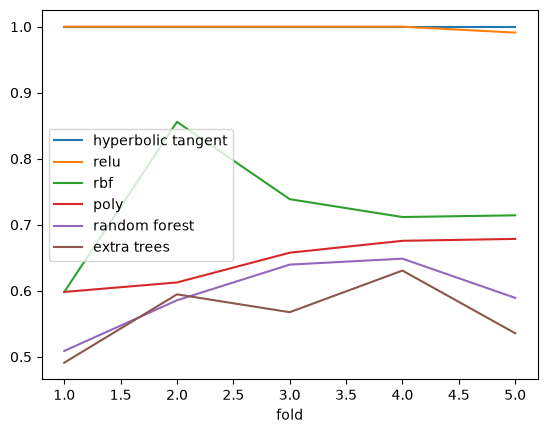

Model 1: 1.0
Model 2: 0.9982142857142857
Model 3: 0.7237612612612613
Model 4: 0.644546332046332
Model 5: 0.594417631917632
Model 6: 0.5639157014157015


In [32]:
import numpy as np
import matplotlib.pyplot as plt

recall_df = pd.DataFrame({
    'fold':[1,2,3,4,5],
    'hyperbolic tangent': recalls_1,
    'relu': recalls_2,
    'rbf': recalls_3,
    'poly': recalls_4,
    'random forest': recalls_5,
    'extra trees': recalls_6
})

recall_df

recall_df.plot(x='fold', y=['hyperbolic tangent', 'relu', 'rbf', 'poly', 'random forest', 'extra trees'], kind='line')

plt.show()
    
print(f"Model 1: {np.mean(recalls_1)}")
print(f"Model 2: {np.mean(recalls_2)}")
print(f"Model 3: {np.mean(recalls_3)}")
print(f"Model 4: {np.mean(recalls_4)}")
print(f"Model 5: {np.mean(recalls_5)}")
print(f"Model 6: {np.mean(recalls_6)}")


_Discuss your conclusion here._`
based off the results i would use the model 1 because it has the highest recall.